# <center> BREAST CANCER PREDICTION
    
![](https://www.dadberg.com/wp-content/uploads/2021/04/f-958x575.png)
    
    - Breast cancer is the most common invasive cancer in women and the second leading cause of cancer death in women after lung cancer.
    -  The Wisconsin Breast Cancer dataset is obtained from a prominent machine learning database named UCI machine learning database. Using the Breast Cancer Wisconsin (Diagnostic) Database, we can create a classifier that can help diagnose patients and predict the likelihood of a breast cancer.
    - In this Notebbok I have used almost all useful classifiers for classification of breast cancer being benign or malignant.
    - Before feeding the data into Classifying Model, I have preprocessed it by dimension reducing technique of PCA(Principle Component Analysis).

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
#reading the csv data file
df =  pd.read_csv('../input/breast-cancer-wisconsin-data/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Exploring the data

In [3]:
df.shape

(569, 33)

In [4]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df = df.drop(['Unnamed: 32'],axis=1)

In [7]:
df.shape

(569, 32)

In [8]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
df.corr()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,-0.022114,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
radius_mean,0.074626,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,-0.022114,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


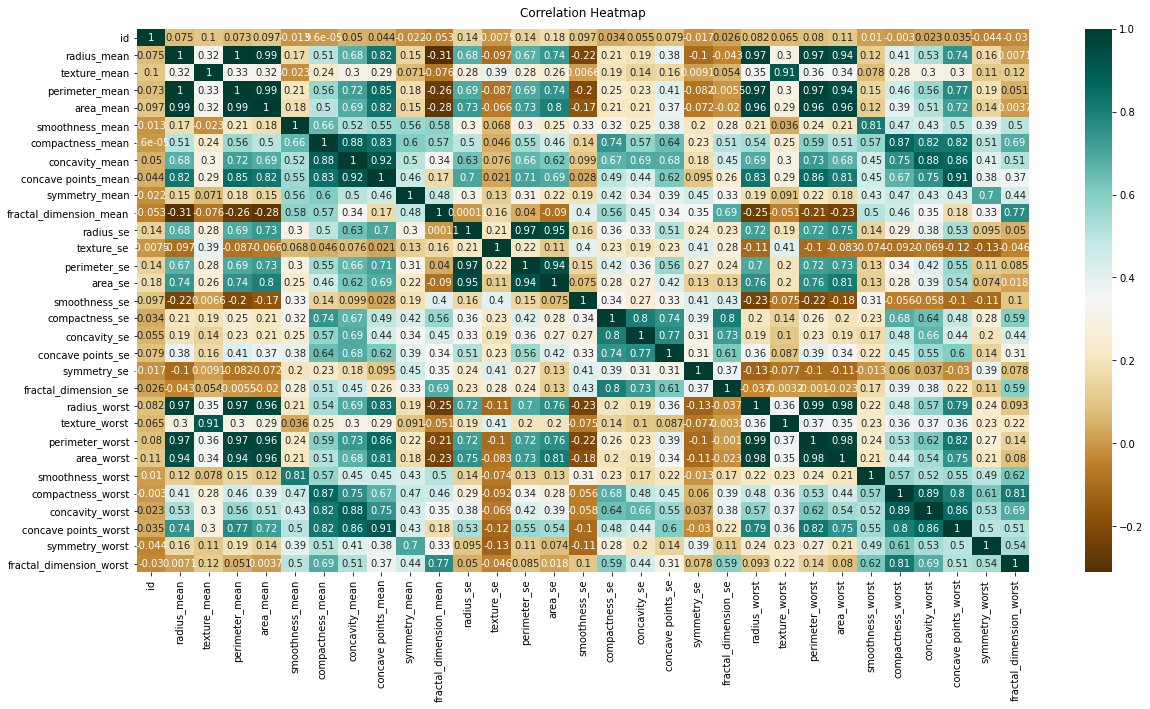

In [15]:
# PLOTTING HEATMAP FOR VISUALISING CORRELATION BETWEEN FEATURES
plt.figure(figsize=(20, 10))
heatmap = sb.heatmap(df.corr(),cmap='BrBG',annot=True)
# Give a title to the heatmap. Pad defines the distance of the title from the top of the heatmap.
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

<AxesSubplot:xlabel='diagnosis'>

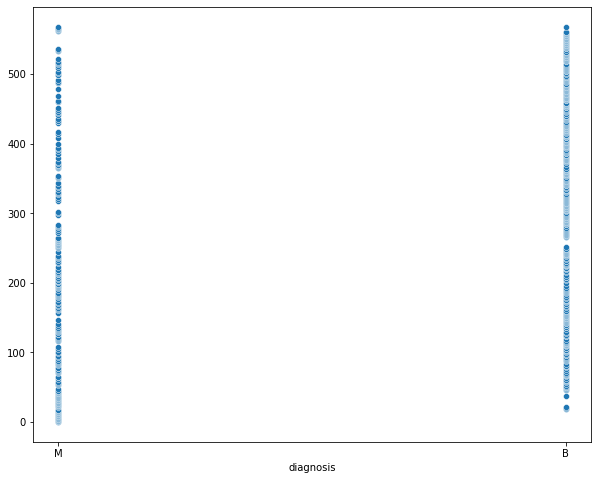

In [17]:
#check the balance in deendent feature
plt.figure(figsize=(10, 8))
sb.scatterplot(y = df.index , x= df.diagnosis,palette = 'BrBe')

<AxesSubplot:xlabel='concavity_mean', ylabel='Density'>

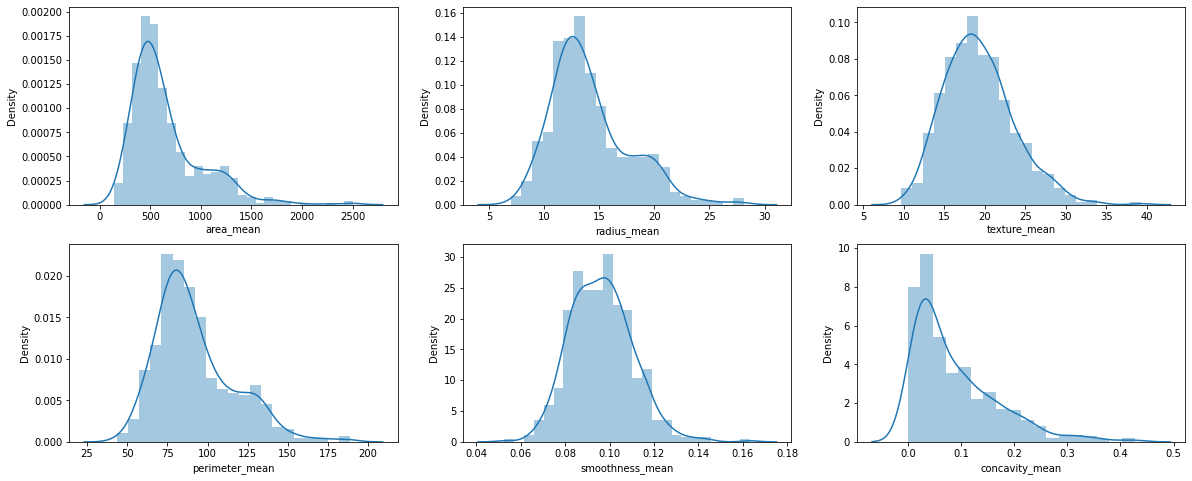

In [18]:
#CHECKING DISTRIBUTION OF DATA IN FEATURES
fig, axes = plt.subplots(2,3,figsize=(20,8))
sb.distplot(df['area_mean'],ax = axes[0,0])
sb.distplot(df['radius_mean'],ax = axes[0,1])
sb.distplot(df['texture_mean'],ax = axes[0,2])
sb.distplot(df['perimeter_mean'],ax = axes[1,0])
sb.distplot(df['smoothness_mean'],ax = axes[1,1])
sb.distplot(df['concavity_mean'],ax = axes[1,2])

In [19]:
#CONVERTING THE CATEGORICAL DATA TO NUMERICAL
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [20]:
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [21]:
df['diagnosis']

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

![](https://miro.medium.com/max/2000/1*KdvxqXIOkb9JY_BeUWvpxg.jpeg)

Principal Component Analysis, or PCA, is a dimensionality-reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information in the large set.
PCA is a very flexible tool and allows analysis of datasets that may contain, for example, multicollinearity, missing values, categorical data, and imprecise measurements. The goal is to extract the important information from the data and to express this information as a set of summary indices called principal components.
    So to sum up, the idea of PCA is simple — reduce the number of variables of a data set, while preserving as much information as possible.
- Read more about PCA in details from [here](https://builtin.com/data-science/step-step-explanation-principal-component-analysis)

![](https://ars.els-cdn.com/content/image/1-s2.0-S2214784516300147-gr1.jpg)

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
scaler.fit(df)

StandardScaler()

In [24]:
scaled_data = scaler.transform(df)

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [26]:
pca.fit(scaled_data)

PCA(n_components=2)

In [27]:
x_pca = pca.transform(scaled_data)

In [28]:
scaled_data.shape, x_pca.shape

((569, 32), (569, 2))

In [29]:
pca_df = pd.DataFrame(data = x_pca, columns = ['principal component 1', 'principal component 2'])
pca_df

,principal component 1,principal component 2
0,9.216724,2.136750
1,2.651244,-3.770741
2,5.900697,-1.010916
3,7.137376,10.315636
4,4.139263,-1.916891
...,...,...
564,6.589934,-3.444874
565,4.020812,-3.546088
566,1.525754,-1.950552
567,10.395832,1.871229


## Visualising PCA

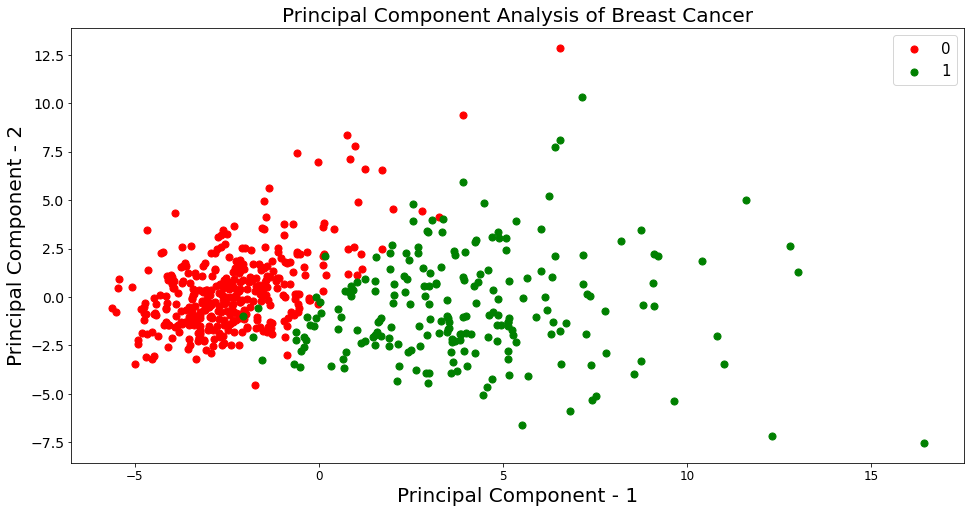

In [30]:
plt.figure(figsize=(16,8))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=20)
plt.ylabel('Principal Component - 2',fontsize=20)
plt.title("Principal Component Analysis of Breast Cancer",fontsize=20)
targets = [0,1]
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = df['diagnosis'] == target
    plt.scatter(pca_df.loc[indicesToKeep, 'principal component 1']
               , pca_df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50)

plt.legend(targets,prop={'size': 15})

## Split data into train and test

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = df[['radius_mean', 'texture_mean', 'perimeter_mean','area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean','radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se','compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst','perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst','symmetry_worst', 'fractal_dimension_worst']]
Y = df[['diagnosis']]

In [33]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.3)

In [34]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((398, 30), (398, 1), (171, 30), (171, 1))

## Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### 1) Logisic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

In [37]:
LR.fit(X_train,Y_train)

LogisticRegression()

In [38]:
Y_LR = LR.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score,confusion_matrix
acc_LR = accuracy_score(Y_test, Y_LR)
print('ACCURACY SCORE: ',acc_LR)
cm_LR = confusion_matrix(Y_test,Y_LR)
print('CONFUSION MATRIX: \n',cm_LR)

ACCURACY SCORE:  0.9883040935672515
CONFUSION MATRIX: 
 [[106   1]
 [  1  63]]


### 2)KNN Classification

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
#Finding best possible number of neighbors
no_of_neighbors_and_accuracies = {}
for i in range(1,15):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train,Y_train)
    Y_knn = knn.predict(X_test)
    score = accuracy_score(Y_knn,Y_test)
    no_of_neighbors_and_accuracies[i] = score

In [48]:
no_of_neighbors_and_accuracies

{1: 0.9415204678362573,
 2: 0.9473684210526315,
 3: 0.9590643274853801,
 4: 0.9590643274853801,
 5: 0.9532163742690059,
 6: 0.9532163742690059,
 7: 0.9532163742690059,
 8: 0.9415204678362573,
 9: 0.9415204678362573,
 10: 0.9532163742690059,
 11: 0.9473684210526315,
 12: 0.9532163742690059,
 13: 0.9532163742690059,
 14: 0.9473684210526315}

- Here we can see that 3 gives highest accuracy, so we'll choose n_neighbors = 3

In [51]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [52]:
Y_knn = knn.predict(X_test)

In [53]:
acc_knn = accuracy_score(Y_test, Y_knn)
print('ACCURACY SCORE: ',acc_knn)
cm_knn = confusion_matrix(Y_test,Y_knn)
print('CONFUSION MATRIX: \n',cm_knn)

ACCURACY SCORE:  0.9590643274853801
CONFUSION MATRIX: 
 [[103   4]
 [  3  61]]


### 3)Decision Tree 

In [54]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='gini')

In [55]:
dtc.fit(X_train,Y_train)

DecisionTreeClassifier()

In [56]:
Y_dtc = dtc.predict(X_test)

In [57]:
acc_dtc = accuracy_score(Y_test, Y_dtc)
print('ACCURACY SCORE: ',acc_dtc)
cm_dtc = confusion_matrix(Y_test,Y_dtc)
print('CONFUSION MATRIX: \n',cm_dtc)

ACCURACY SCORE:  0.9298245614035088
CONFUSION MATRIX: 
 [[100   7]
 [  5  59]]


### 4)Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(criterion='entropy')

In [59]:
rfc.fit(X_train, Y_train)

RandomForestClassifier(criterion='entropy')

In [60]:
Y_rfc = rfc.predict(X_test)

In [61]:
acc_rfc = accuracy_score(Y_test, Y_rfc)
print('ACCURACY SCORE: ',acc_rfc)
cm_rfc = confusion_matrix(Y_test,Y_rfc)
print('CONFUSION MATRIX: \n',cm_rfc)

ACCURACY SCORE:  0.9590643274853801
CONFUSION MATRIX: 
 [[104   3]
 [  4  60]]


### 5)Support Vector Machine

In [62]:
from sklearn.svm import SVC
svc = SVC()

In [63]:
svc.fit(X_train,Y_train)

SVC()

In [64]:
Y_svc = svc.predict(X_test)

In [65]:
acc_svc = accuracy_score(Y_test, Y_svc)
print('ACCURACY SCORE: ',acc_svc)
cm_svc = confusion_matrix(Y_test,Y_svc)
print('CONFUSION MATRIX: \n',cm_svc)

ACCURACY SCORE:  0.9824561403508771
CONFUSION MATRIX: 
 [[106   1]
 [  2  62]]


### 6)Naive Bayes

In [66]:
from sklearn.naive_bayes import GaussianNB  
gnb = GaussianNB() 

In [67]:
gnb.fit(X_train, Y_train)

GaussianNB()

In [68]:
Y_gnb = gnb.predict(X_test) 

In [69]:
acc_gnb = accuracy_score(Y_test, Y_gnb)
print('ACCURACY SCORE: ',acc_gnb)
cm_gnb = confusion_matrix(Y_test,Y_gnb)
print('CONFUSION MATRIX: \n',cm_gnb)

ACCURACY SCORE:  0.9298245614035088
CONFUSION MATRIX: 
 [[102   5]
 [  7  57]]


### 7)Gradient Boosting

In [70]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()

In [71]:
gbc.fit(X_train,Y_train)

GradientBoostingClassifier()

In [72]:
Y_gbc = gbc.predict(X_test)

In [73]:
acc_gbc = accuracy_score(Y_test, Y_gbc)
print('ACCURACY SCORE: ',acc_gbc)
cm_gbc = confusion_matrix(Y_test,Y_gbc)
print('CONFUSION MATRIX: \n',cm_gbc)

ACCURACY SCORE:  0.9415204678362573
CONFUSION MATRIX: 
 [[102   5]
 [  5  59]]


### 8)Stochastic Gradient Decent

In [74]:
from sklearn.linear_model import SGDClassifier
sgdc = SGDClassifier()

In [75]:
Y_sgdc = sgdc.fit(X_train,Y_train)

In [76]:
Y_sgdc = sgdc.predict(X_test)

In [77]:
acc_sgdc = accuracy_score(Y_test, Y_sgdc)
print('ACCURACY SCORE: ',acc_sgdc)
cm_sgdc = confusion_matrix(Y_test,Y_sgdc)
print('CONFUSION MATRIX: \n',cm_sgdc)

ACCURACY SCORE:  0.9590643274853801
CONFUSION MATRIX: 
 [[102   5]
 [  2  62]]


### 8)AdaBoost

In [78]:
from sklearn.ensemble import AdaBoostClassifier
adb = AdaBoostClassifier()

In [79]:
adb.fit(X_train,Y_train)

AdaBoostClassifier()

In [80]:
Y_adb = adb.predict(X_test)

In [81]:
acc_adb = accuracy_score(Y_test, Y_adb)
print('ACCURACY SCORE: ',acc_adb)
cm_adb = confusion_matrix(Y_test,Y_adb)
print('CONFUSION MATRIX: \n',cm_adb)

ACCURACY SCORE:  0.9824561403508771
CONFUSION MATRIX: 
 [[107   0]
 [  3  61]]


### 9)XGBoost

In [82]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

In [83]:
xgb.fit(X_train,Y_train)

[10:37:17] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [84]:
Y_xgb = xgb.predict(X_test)

In [85]:
acc_xgb = accuracy_score(Y_test, Y_xgb)
print('ACCURACY SCORE: ',acc_xgb)
cm_xgb = confusion_matrix(Y_test,Y_xgb)
print('CONFUSION MATRIX: \n',cm_xgb)

ACCURACY SCORE:  0.9532163742690059
CONFUSION MATRIX: 
 [[103   4]
 [  4  60]]


### 10)CatBoost

In [86]:
from catboost import CatBoostClassifier
cb = CatBoostClassifier()

In [87]:
cb.fit(X_train,Y_train)

Learning rate set to 0.006952
0:	learn: 0.6821278	total: 54.2ms	remaining: 54.1s
1:	learn: 0.6716296	total: 58.6ms	remaining: 29.2s
2:	learn: 0.6613007	total: 62.7ms	remaining: 20.8s
3:	learn: 0.6511965	total: 67ms	remaining: 16.7s
4:	learn: 0.6399925	total: 71.2ms	remaining: 14.2s
5:	learn: 0.6309262	total: 75.6ms	remaining: 12.5s
6:	learn: 0.6196176	total: 79.8ms	remaining: 11.3s
7:	learn: 0.6097579	total: 84ms	remaining: 10.4s
8:	learn: 0.5981160	total: 88.5ms	remaining: 9.74s
9:	learn: 0.5895839	total: 92.8ms	remaining: 9.19s
10:	learn: 0.5811619	total: 97.1ms	remaining: 8.73s
11:	learn: 0.5726778	total: 101ms	remaining: 8.34s
12:	learn: 0.5640201	total: 106ms	remaining: 8.02s
13:	learn: 0.5557932	total: 110ms	remaining: 7.74s
14:	learn: 0.5472312	total: 114ms	remaining: 7.51s
15:	learn: 0.5396170	total: 119ms	remaining: 7.31s
16:	learn: 0.5324238	total: 123ms	remaining: 7.12s
17:	learn: 0.5248183	total: 127ms	remaining: 6.94s
18:	learn: 0.5169843	total: 131ms	remaining: 6.78s
19:	

In [88]:
Y_cb = cb.predict(X_test)

In [89]:
acc_cb = accuracy_score(Y_test, Y_cb)
print('ACCURACY SCORE: ',acc_cb)
cm_cb = confusion_matrix(Y_test,Y_cb)
print('CONFUSION MATRIX: \n',cm_cb)

ACCURACY SCORE:  0.9649122807017544
CONFUSION MATRIX: 
 [[105   2]
 [  4  60]]


### 11)Light GBM

In [90]:
from lightgbm import LGBMClassifier

In [91]:
lg = LGBMClassifier()

In [92]:
lg.fit(X_train,Y_train)

LGBMClassifier()

In [93]:
Y_lg = lg.predict(X_test)

In [94]:
acc_lg = accuracy_score(Y_test, Y_lg)
print('ACCURACY SCORE: ',acc_lg)
cm_lg = confusion_matrix(Y_test,Y_lg)
print('CONFUSION MATRIX: \n',cm_lg)

ACCURACY SCORE:  0.9766081871345029
CONFUSION MATRIX: 
 [[106   1]
 [  3  61]]


In [95]:
models = pd.DataFrame({
    'Model': ['Logistic Regression','KNN','Decision Tree','Random Forest','Support Vector Machines',
              'Naive Bayes','Gradient Boosting','Stochastic gradient decent','AdaBoost','XGboost','Catboost','LightGBM'],
    'Score': [acc_LR, acc_knn, acc_dtc,acc_rfc, acc_svc, acc_gnb, acc_gbc, acc_sgdc, acc_adb, acc_xgb, acc_cb, acc_lg]})
models.sort_values(by='Score', ascending=False)

,Model,Score
0,Logistic Regression,0.988304
4,Support Vector Machines,0.982456
8,AdaBoost,0.982456
11,LightGBM,0.976608
10,Catboost,0.964912
1,KNN,0.959064
3,Random Forest,0.959064
7,Stochastic gradient decent,0.959064
9,XGboost,0.953216
6,Gradient Boosting,0.941520


## We can conclude that Logistic Regression & SVM gives the highest possible accuracy which is 98.8%

### Thank you. Consider **UPVOTING** if you find it useful :)